# 06. Временной backtest

**Цель:** сравнить устойчивость LightGBM и XGBoost на трёх временных окнах.
**Условия:** растущий train, по одному дню на validation и evaluation; дневной top-k — 0,1% транзакций. Текущий test исключён; OTE заново обучается в каждом окне и предполагает немедленную доступность меток.

[Результаты backtest](../reports/backtest/RESULTS.md)

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import joblib
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").exists() and (p / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Запустите notebook из корня проекта или notebooks")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from aml.workflow import (TARGET, CATEGORICAL, OrderedTargetEncoder, load_raw, temporal_slices,
    basic_features, historical_features, rolling_windows, budget_metrics, ranking_metrics, new_run)
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
SEED = 42
ALERT_FRACTION = 0.001
NEGATIVE_SAMPLE_RATIO = 0.39
N_FOLDS = 3
ITERATIONS = 800
BACKTEST_DIR = new_run(PROJECT_ROOT / "artifacts", "backtests")
config = {"seed": SEED, "alert_fraction": ALERT_FRACTION,
    "negative_sample_ratio": NEGATIVE_SAMPLE_RATIO, "folds": N_FOLDS,
    "initial_days": 3, "validation_days": 1, "evaluation_days": 1,
    "iterations": ITERATIONS, "learning_rate": 0.05,
    "xgboost_max_depth": 6, "lightgbm_num_leaves": 31}
(BACKTEST_DIR / "configuration.json").write_text(json.dumps(config, indent=2))


260

## Временные окна

In [2]:
raw = load_raw(PROJECT_ROOT)
cutoff = temporal_slices(raw["Timestamp"])["test"].start
raw = raw.iloc[:cutoff].copy().reset_index(drop=True)
timestamp = raw["Timestamp"].copy()
y = raw[TARGET].copy()
folds = rolling_windows(timestamp, n_folds=N_FOLDS)
X = historical_features(basic_features(raw), timestamp)
del raw
window_table = pd.DataFrame([{"fold": i, "partition": name, "rows": len(y.iloc[s]),
    "positives": int(y.iloc[s].sum()), "start": timestamp.iloc[s].min(), "end": timestamp.iloc[s].max()}
    for i, fold in enumerate(folds, 1) for name, s in fold.items()])
window_table.to_csv(BACKTEST_DIR / "windows.csv", index=False)
display(window_table)
if any(y.iloc[s].nunique() < 2 for fold in folds for s in fold.values()):
    raise ValueError("A fold lacks both classes: revise windows before making model comparisons")


,fold,partition,rows,positives,start,end
0,1,train,2835888,952,2022-09-01,2022-09-03 23:59:00
1,1,val,282476,291,2022-09-04,2022-09-04 23:59:00
2,1,evaluation,657396,370,2022-09-05,2022-09-05 23:59:00
3,2,train,3118364,1243,2022-09-01,2022-09-04 23:59:00
4,2,val,657396,370,2022-09-05,2022-09-05 23:59:00
5,2,evaluation,657169,380,2022-09-06,2022-09-06 23:59:00
6,3,train,3775760,1613,2022-09-01,2022-09-05 23:59:00
7,3,val,657169,380,2022-09-06,2022-09-06 23:59:00
8,3,evaluation,658502,368,2022-09-07,2022-09-07 23:59:00


## Обучение моделей

Параметры фиксированы; модели используют одинаковые признаки, строки и веса. Метки validation/evaluation не входят в encoder.

In [3]:
results = []
interactions = [("From Bank", "Account"), ("To Bank", "Account.1"),
                ("From Bank", "To Bank"), ("Receiving Currency", "Payment Currency")]
for fold_number, fold in enumerate(folds, 1):
    fold_dir = BACKTEST_DIR / f"fold_{fold_number}"
    fold_dir.mkdir()
    train, val, evaluation = (fold[k] for k in ("train", "val", "evaluation"))
    encoder = OrderedTargetEncoder(CATEGORICAL, interactions)
    train_encoded = encoder.fit_transform(X.iloc[train], y.iloc[train], timestamp.iloc[train])
    val_encoded = encoder.transform(X.iloc[val])
    eval_encoded = encoder.transform(X.iloc[evaluation])
    y_train, y_val, y_eval = (y.iloc[s].reset_index(drop=True) for s in (train, val, evaluation))
    negative = np.flatnonzero(y_train.to_numpy() == 0)
    positive = np.flatnonzero(y_train.to_numpy() == 1)
    n_negative = max(1, int(NEGATIVE_SAMPLE_RATIO * len(negative)))
    rng = np.random.default_rng(SEED + fold_number)
    positions = np.sort(np.r_[positive, rng.choice(negative, n_negative, replace=False)])
    X_fit, y_fit = train_encoded.iloc[positions], y_train.iloc[positions]
    weights = np.where(y_fit.to_numpy() == 0, len(negative) / n_negative, 1.)
    models = {
        "LightGBM": LGBMClassifier(n_estimators=ITERATIONS, learning_rate=0.05, num_leaves=31,
            objective="binary", metric="average_precision", random_state=SEED, n_jobs=4, verbosity=-1),
        "XGBoost": XGBClassifier(n_estimators=ITERATIONS, learning_rate=0.05, max_depth=6,
            objective="binary:logistic", eval_metric="aucpr", tree_method="hist", max_bin=128,
            early_stopping_rounds=100, random_state=SEED, n_jobs=4),
    }
    for name, model in models.items():
        if name == "LightGBM":
            from aml.workflow import lightgbm_validation
            model.fit(X_fit, y_fit, sample_weight=weights,
                **lightgbm_validation(val_encoded, y_val),
                callbacks=[lgb.early_stopping(100, verbose=False)])
        else:
            model.fit(X_fit, y_fit, sample_weight=weights,
                      eval_set=[(val_encoded, y_val)], verbose=False)
        scores = model.predict_proba(eval_encoded)[:, 1]
        operational = budget_metrics(y_eval, scores, timestamp.iloc[evaluation], ALERT_FRACTION)
        results.append({"fold": fold_number, "model": name,
                        **ranking_metrics(y_eval, scores), **operational.to_dict()})
        joblib.dump(model, fold_dir / f"{name}.joblib")
        pd.DataFrame(results).to_csv(BACKTEST_DIR / "fold_metrics.csv", index=False)
    joblib.dump(encoder, fold_dir / "encoder.joblib")
    del train_encoded, val_encoded, eval_encoded, X_fit, encoder, models
results = pd.DataFrame(results)
display(results)


,fold,model,AP,ROC-AUC,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
0,1,LightGBM,0.100724,0.859042,657396.0,370.0,96.0,561.0,274.0,657.0,0.146119,0.259459,0.000999
1,1,XGBoost,0.232914,0.977497,657396.0,370.0,113.0,544.0,257.0,657.0,0.171994,0.305405,0.000999
2,2,LightGBM,0.201399,0.879334,657169.0,380.0,107.0,550.0,273.0,657.0,0.162861,0.281579,0.001000
3,2,XGBoost,0.246450,0.979051,657169.0,380.0,116.0,541.0,264.0,657.0,0.176560,0.305263,0.001000
4,3,LightGBM,0.169336,0.845964,658502.0,368.0,103.0,555.0,265.0,658.0,0.156535,0.279891,0.000999
5,3,XGBoost,0.244791,0.975909,658502.0,368.0,119.0,539.0,249.0,658.0,0.180851,0.323370,0.000999


## Сравнение по окнам

Средние и стандартные отклонения описывают три окна, а не доверительные интервалы.

AP                                  recall            \
              mean       std       min       max      mean       std   
model                                                                  
LightGBM  0.157153  0.051432  0.100724  0.201399  0.273643  0.012312   
XGBoost   0.241385  0.007383  0.232914  0.246450  0.311346  0.010413   

                             precision                                \
               min       max      mean       std       min       max   
model                                                                  
LightGBM  0.259459  0.281579  0.155172  0.008454  0.146119  0.162861   
XGBoost   0.305263  0.323370  0.176468  0.004429  0.171994  0.180851   

         alert_rate                                 
               mean           std       min    max  
model                                               
LightGBM   0.000999  2.581855e-07  0.000999  0.001  
XGBoost    0.000999  2.581855e-07  0.000999  0.001

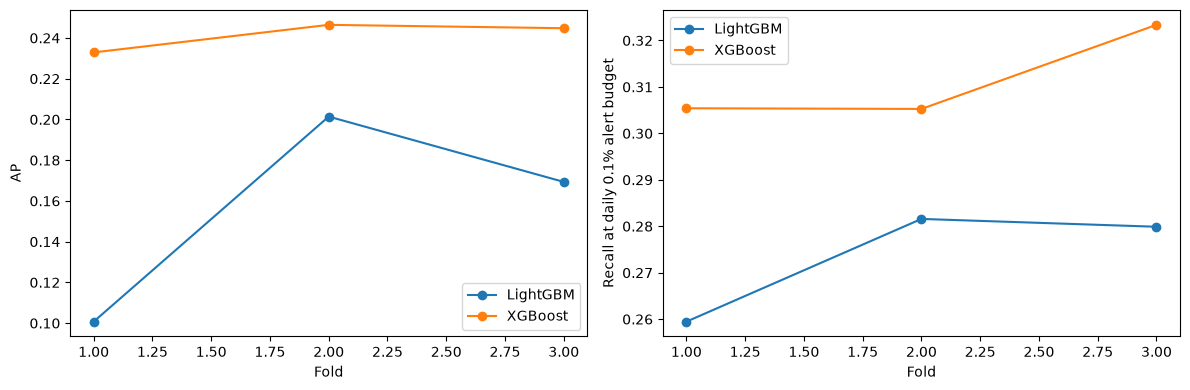

In [4]:
summary = results.groupby("model")[["AP", "recall", "precision", "alert_rate"]].agg(["mean", "std", "min", "max"])
summary.to_csv(BACKTEST_DIR / "summary.csv")
display(summary)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, group in results.groupby("model"):
    axes[0].plot(group["fold"], group["AP"], "o-", label=name)
    axes[1].plot(group["fold"], group["recall"], "o-", label=name)
axes[0].set(xlabel="Fold", ylabel="AP")
axes[1].set(xlabel="Fold", ylabel="Recall at daily 0.1% alert budget")
for ax in axes: ax.legend()
plt.tight_layout()
fig.savefig(BACKTEST_DIR / "backtest.png", dpi=150)
plt.show()


## Выводы

Средние по трём окнам при дневном бюджете алертов 0,1%:

| Модель | AP, среднее ± std | Recall | Precision |
|---|---:|---:|---:|
| LightGBM | 0,1572 ± 0,0514 | 27,36% | 15,52% |
| XGBoost | **0,2414 ± 0,0074** | **31,13%** | **17,65%** |

- XGBoost лучше по AP и recall во всех трёх окнах; средний выигрыш recall — 3,77 п.п.
- AP XGBoost меняется от 0,2329 до 0,2464: разброс меньше, чем у LightGBM. При этом пропускается около 69% положительных.
- Вывод относится к фиксированным конфигурациям и трём связанным development-окнам, не к новому независимому test. Показатели напрямую несопоставимы с notebook 04: отличаются периоды и политика алертов.